In [6]:
import json 
import matplotlib.pyplot as plt

In [7]:

def parse_json(json_file):
    with open(json_file,'r') as f : 
        data = json.load(f)
    dates=[]
    values=[]
    prices=[]
    transaction_costs=[]
    for hedging_data in data: 
        dates.append(hedging_data['time'])
        values.append(hedging_data['portfolio_value'])
        prices.append(hedging_data['option_price'])
        transaction_costs.append(hedging_data['transaction_costs'])
    
    return dates,values,prices,transaction_costs


In [10]:
def plot(dates,values,prices,transaction_costs,title,show_costs=True):
    plt.plot(dates,values,color='red',label='Portfolio value')
    plt.plot(dates,prices,color='black',label='Option price')
    if show_costs :
        plt.plot(dates,transaction_costs,color='blue',label='Transaction costs')
    plt.title(title)
    plt.xlabel('Time (years)')
    plt.ylabel('Value')
    plt.legend()
    plt.show()


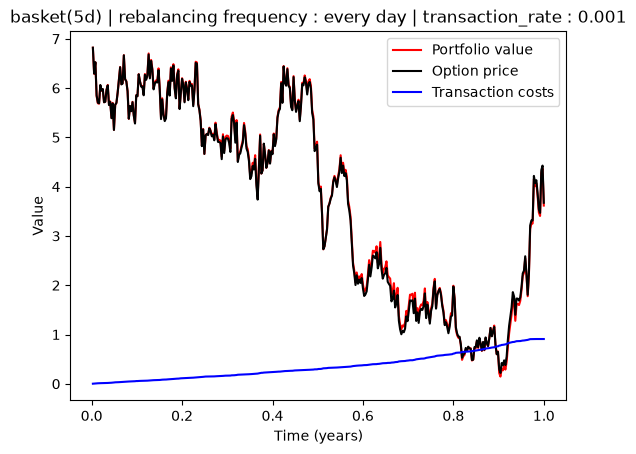

In [11]:
dates,values,prices,transaction_costs= parse_json('./hedging_data/basket_5d_hedging.json')
plot(dates,values,prices,transaction_costs,'basket(5d) | rebalancing frequency : every day | transaction_rate : 0.001')

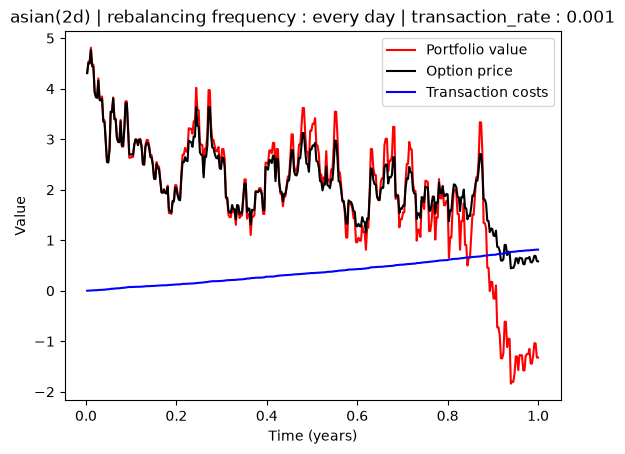

In [14]:
dates,values,prices,transaction_costs= parse_json('./hedging_data/asian_hedging.json')
plot(dates,values,prices,transaction_costs,'asian(2d) | rebalancing frequency : every day | transaction_rate : 0.001')

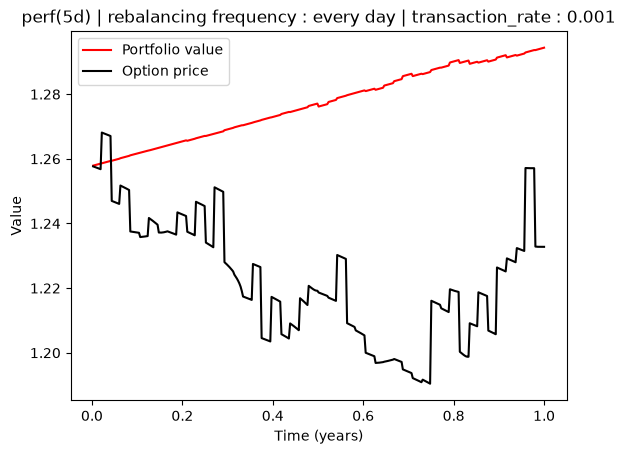

In [16]:
dates,values,prices,transaction_costs= parse_json('./hedging_data/perf_hedging.json')
plot(dates,values,prices,transaction_costs,'perf(5d) | rebalancing frequency : every day | transaction_rate : 0.001',show_costs=False)